# Setup

In [5]:
#!curl -L -o ~/Code/eec-289a/urbansound8k.zip https://www.kaggle.com/api/v1/datasets/download/chrisfilo/urbansound8k


# Synthesis
        

In [1]:
# Imports
import os
import random
import zipfile
from pathlib import Path
import tqdm.auto as tqdm
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, Audio, HTML

from audio_extract import *     # feature extraction, ZCA, K-means, spectral decomp
from Algos import *             # synthesize_audio_mfcc, synthesize_audio_ablation, reconstruct_audio, …
from eval_metrics import *      # kl_mfcc_divergence, composite_score, evaluate_synthesis_run, …
from grid_search import *       # run_grid_config, fista_sparse_numpy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def setup(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def set_seed(seed: int = 0):
    """Alias for setup() to maintain compatibility with grid search code."""
    setup(seed)

setup()
audio_files = setup_audio_dataset(Path("~/Code/eec-289/Final-Proj").expanduser(), "urbansound8k.zip")

# ── Global constants (defined once here so every cell works standalone) ───────

# Environmental synthesis
N_MFCC         = 20        # MFCC coefficients for environmental audio
SMT_DICT_SIZE  = 128       # K-means atoms / SMT dictionary size
SMT_EMBED_DIM  = 128       # spectral manifold embedding dimension
OUT_TIME_STEPS = 500       # output frames for full-length synthesis

OUTPUT_DIR = Path("~/Code/eec-289/Final-Proj/generated_audio").expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Speech synthesis
TARGET_SR       = 16_000   # LibriSpeech sample rate (Hz)
SPEECH_N_MFCC   = 40       # MFCC coefficients for speech
SPEECH_PATCH_MS = 25.0     # patch width (ms)
SPEECH_HOP_MS   = 10.0     # frame hop (ms)
SPEECH_WIN_MS   = 20.0     # analysis window (ms)
SPEECH_EPS_SSD  = 0.10     # Pillar 1: tight SSD epsilon (texture match)
SPEECH_EPS_SMT  = 0.40     # Pillar 3: wider SMT epsilon (semantic variety)
SPEECH_R_LOC    = 1.0      # locality radius (1.0 = disabled / global search)
SPEECH_H_MULT   = 0.30     # weighted-sampler temperature


Run the synthesis loop above first to populate `audio_stitched`.
Directory 'extracted_audio' already exists and is not empty. Skipping extraction.
Found 8732 files. Preview: ['100032-3-0-0.wav', '100263-2-0-117.wav', '100263-2-0-121.wav', '100263-2-0-126.wav', '100263-2-0-137.wav']


# Synthesis

## Analytical Evaluation Metrics

Four complementary scores computed entirely from the synthesis outputs — no listening required.

| Metric | What it measures | Better when |
|---|---|---|
| **KL divergence** | Per-coefficient MFCC histogram match: source center-frames vs output | Lower |
| **Patch diversity** | Fraction of unique source patches chosen | Higher (avoids looping) |
| **Temporal continuity** | Mean cosine similarity between consecutive output frames | Higher (smooth transitions) |
| **Source coverage** | Fraction of the source pool used at least once | Higher (exploits corpus) |

## Patch Size Grid Search — Full Three-Pillar Synthesis

**Why patch size matters for short outputs:**

| Rule of thumb | Detail |
|---|---|
| Patch should be **5–15% of output length** | Too wide → structural repetition; too narrow → no useful context |
| At 5 s output (500 frames × 10 ms) | Sweet spot: **25–75 ms** (2–8 frames of context) |
| Very narrow (≤10 ms, W=1–2) | Degenerate — SSD can't discriminate neighbours; random-walk behaviour |
| Very wide (≥100 ms, W=10+) | Context good but flat dim grows; most of patch is unknown zeros during early synthesis |

**What this cell does:** sweeps `patch_ms ∈ {5, 10, 25, 50, 75, 100}` and `hop_ms ∈ {5, 10}` over a single source file, running the **full three-pillar SMT sampler** (ZCA → K-means → spectral decomp → FISTA) for each config and synthesizing **5 seconds** of audio.  Each result is saved as `patch_grid_p{X}ms_h{Y}ms_<stem>.wav` and played inline.


Loading 30 utterances from LibriSpeech dev-clean (2703 total)...
  30 utterances loaded  (240.6 s total)
Building corpus state (ZCA → K-means → spectral decomp)...
  24,116 patches  (W_t=2, flat_dim=80)
  SMT basis: (80, 127)


Synthesizing utterance 1  (seed=67334, es=0.1, et=0.4)...


  0%|          | 2/500 [00:00<00:36, 13.56it/s]

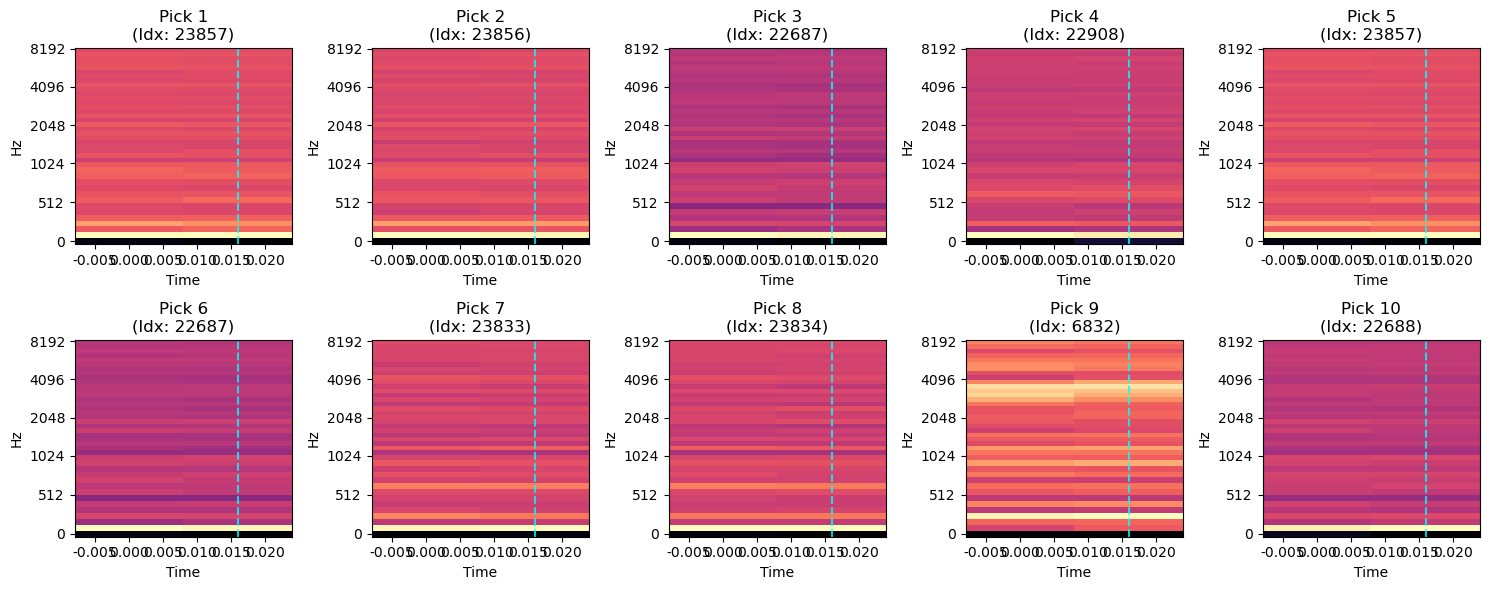

100%|██████████| 500/500 [00:02<00:00, 177.63it/s]


Synthesizing utterance 2  (seed=67335, es=0.1, et=0.4)...


  0%|          | 0/500 [00:00<?, ?it/s]

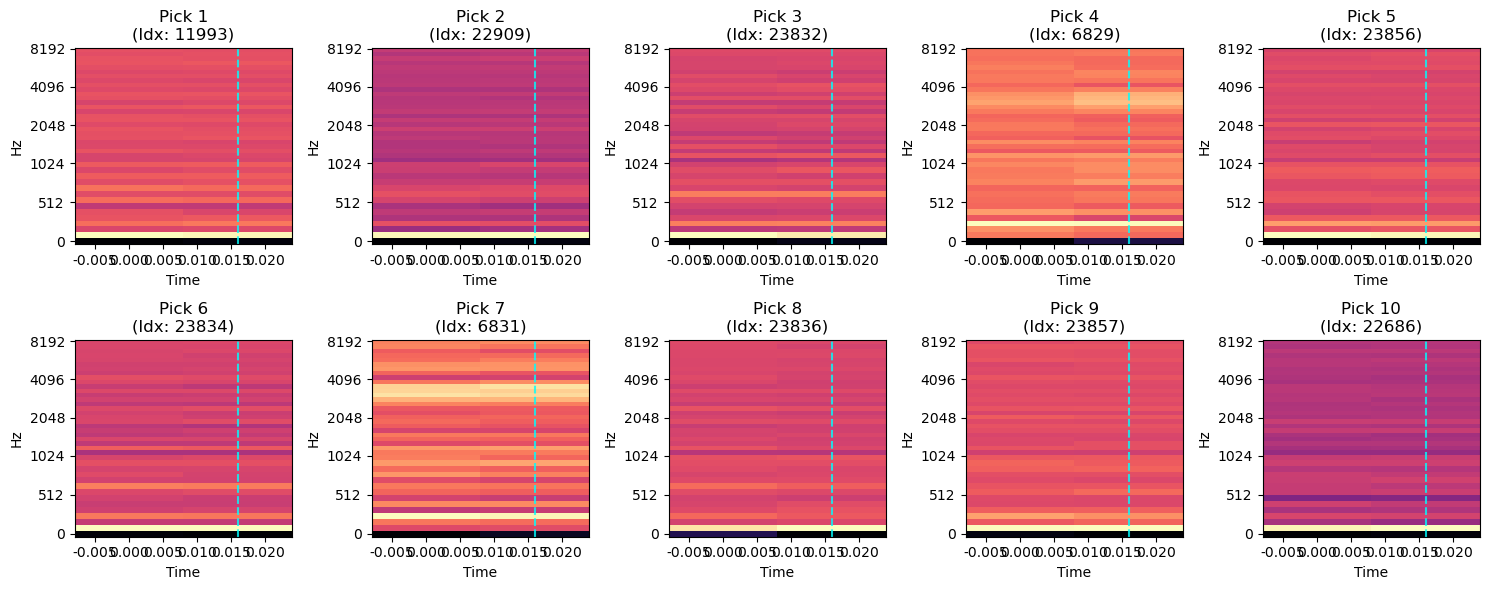

100%|██████████| 500/500 [00:02<00:00, 186.77it/s]



Speech synthesis complete.


In [2]:
import time as _time
from speech_synth import load_speech_corpus, build_corpus_state, synthesize_speech

# ── Configuration ─────────────────────────────────────────────────────────────
SPEECH_DATA_DIR   = Path("~/Code/eec-289/Final-Proj/librispeech_data").expanduser()
NUM_SPEECH_CORPUS = 30     
NUM_SPEECH_SYNTH  = 2      
SPEECH_OUT_STEPS  = 500    

# ── NEW: Dual-Epsilon & Sampling Parameters ───────────────────────────────────
SPEECH_R_LOC      = 1.0    # Locality (DISABLED/1.0 = global search)
SPEECH_EPS_SSD    = 0.10   # Pillar 1: Tight texture matching (prevents glitching)
SPEECH_EPS_SMT    = 0.40   # Pillar 3: Wider semantic matching (boosts variety)
SPEECH_H_MULT     = 0.30   # Temperature for the weighted sampler

# ── Speech MFCC / patch parameters ───────────────────────────────────────────
SPEECH_N_MFCC   = 40
SPEECH_PATCH_MS = 25.0   
SPEECH_HOP_MS   = 10.0   
SPEECH_WIN_MS   = 20.0   
TARGET_SR       = 16_000  

# ── Step 1: Load raw audio (unchanged) ────────────────────────────────────────
corpus_raw_audio_list = load_speech_corpus(
    data_dir     = SPEECH_DATA_DIR,
    n_utterances = NUM_SPEECH_CORPUS,
    target_sr    = TARGET_SR,
    seed         = 0,
)

# ── Step 2: Build corpus state (unchanged) ────────────────────────────────────
print("Building corpus state (ZCA → K-means → spectral decomp)...")
corpus_state = build_corpus_state(
    raw_audio_list = corpus_raw_audio_list,
    target_sr      = TARGET_SR,
    n_mfcc         = SPEECH_N_MFCC,
    patch_ms       = SPEECH_PATCH_MS,
    hop_ms         = SPEECH_HOP_MS,
    win_ms         = SPEECH_WIN_MS,
    smt_dict_size  = SMT_DICT_SIZE,
    smt_embed_dim  = SMT_EMBED_DIM,
)

# Expose torch tensors for the hyperparameter grid search cell below
speech_patches_tensor = corpus_state["patches_tensor"]
smt_basis_speech      = corpus_state["smt_basis"]

# ── Step 3: Synthesize a few demo utterances ──────────────────────────────────
speech_output_dir = OUTPUT_DIR / "speech"
speech_output_dir.mkdir(parents=True, exist_ok=True)

# Use a time-based base seed so each cell execution produces different audio.
# Each synthesis i within the same run still gets a unique seed offset.
_run_seed_base = int(_time.time()) % 100_000

for i in range(min(NUM_SPEECH_SYNTH, len(corpus_raw_audio_list))):
    display(HTML(f"<b>Original Speech:</b> corpus utterance {i + 1}"))
    display(Audio(corpus_raw_audio_list[i], rate=TARGET_SR))

    _seed = _run_seed_base + i
    print(f"Synthesizing utterance {i + 1}  (seed={_seed}, es={SPEECH_EPS_SSD}, et={SPEECH_EPS_SMT})...")
    audio_out = synthesize_speech(
        corpus_state = corpus_state,
        out_steps    = SPEECH_OUT_STEPS,
        r_loc        = SPEECH_R_LOC,
        eps_ssd      = SPEECH_EPS_SSD,
        eps_smt      = SPEECH_EPS_SMT,
        h_mult       = SPEECH_H_MULT,
        weighted     = True,
        seed         = _seed,
    )

    out_path = speech_output_dir / f"speech_synth_stochastic_{i + 1}.wav"
    sf.write(str(out_path), audio_out, TARGET_SR)
    display(HTML(f"<b>Synthesized Speech (Stochastic SMT):</b> {out_path.name}"))
    display(Audio(audio_out, rate=TARGET_SR))

print("\nSpeech synthesis complete.")


Corpus: 24,116 patches  |  variance range [789.4493, 9953.9277]

Showing top-8 highest-variance patches and bottom-4 lowest-variance patches.

TOP-8 HIGHEST-VARIANCE PATCHES  (the old 'seed')


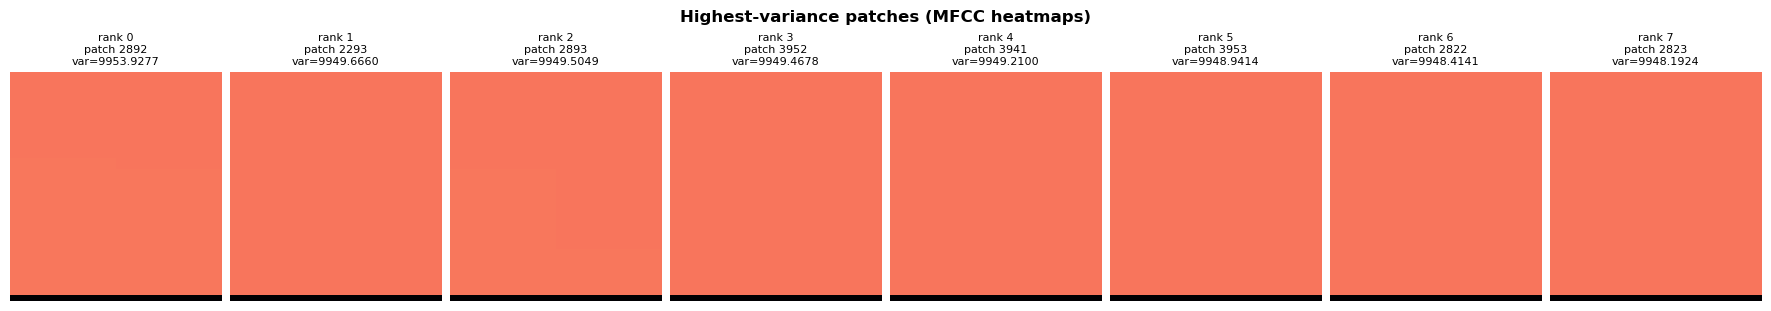


BOTTOM-4 LOWEST-VARIANCE PATCHES  (silence / steady)


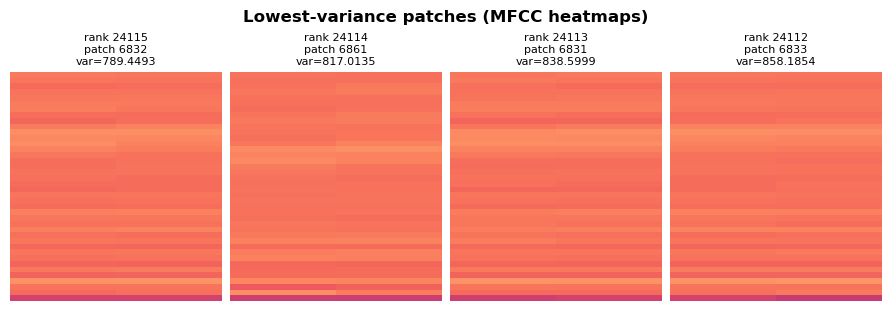

/tmp/ipykernel_1997603/3980982515.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


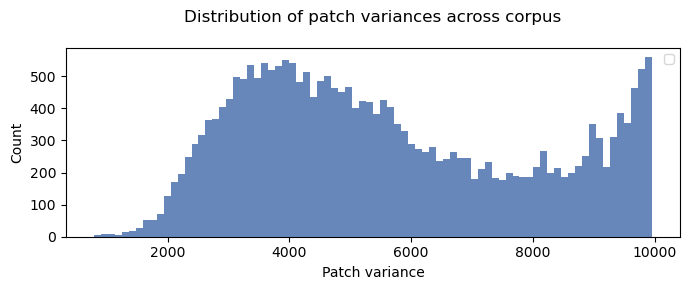

In [3]:
TOP_K = 8       # how many patches to inspect at each end of the variance ranking
BOTTOM_K = 4    # how many low-variance (quiet/silence) patches to show for contrast

# ── Pull tensors out of corpus_state ─────────────────────────────────────────
_patches  = corpus_state["patches_tensor"]   # (N, 1, n_mfcc, W_t)
_hop      = corpus_state["hop_length"]       # samples per MFCC frame
_W_t      = corpus_state["W_t"]             # frames per patch
_audio    = corpus_state["corpus_audio_cat"] # concatenated corpus waveform
_sr       = corpus_state["target_sr"]

# ── Compute per-patch variance (scalar for each of the N patches) ─────────────
# Shape: (N, 1, n_mfcc, W_t)  →  var over all dims except batch  →  (N,)
_var = _patches.var(dim=(1, 2, 3)).cpu()    # (N,)
_sorted_idx = _var.argsort(descending=True) # highest variance first
v_min = _patches.min().item()
v_max = _patches.max().item()
print(f"Corpus: {_patches.shape[0]:,} patches  |  "
      f"variance range [{_var.min():.4f}, {_var.max():.4f}]")
print(f"\nShowing top-{TOP_K} highest-variance patches "
      f"and bottom-{BOTTOM_K} lowest-variance patches.\n")

# ── Helper: sample offset for patch p  →  frame p * hop_length ───────────────
def _patch_audio(p_idx: int, n_extra_frames: int = 0) -> np.ndarray:
    """Return the audio chunk corresponding to patch p_idx (+ optional extra frames)."""
    frame_start = int(p_idx)
    sample_start = frame_start * _hop
    n_frames = _W_t + n_extra_frames
    sample_end = sample_start + n_frames * _hop
    chunk = _audio[sample_start:sample_end]
    if len(chunk) < n_frames * _hop:
        chunk = np.pad(chunk, (0, n_frames * _hop - len(chunk)))
    return chunk.astype(np.float32)

# ─────────────────────────────────────────────────────────────────────────────
# HIGH-VARIANCE patches
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print(f"TOP-{TOP_K} HIGHEST-VARIANCE PATCHES  (the old 'seed')")
print("=" * 60)

fig, axes = plt.subplots(1, TOP_K, figsize=(TOP_K * 2.2, 3), constrained_layout=True)
for rank, ax in enumerate(axes):
    p = int(_sorted_idx[rank].item())
    mfcc_patch = _patches[p, 0].cpu().numpy()   # (n_mfcc, W_t)
    ax.imshow(mfcc_patch, origin="lower", aspect="auto", cmap="magma", 
          vmin=v_min, vmax=v_max)
    ax.set_title(f"rank {rank}\npatch {p}\nvar={_var[p]:.4f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Highest-variance patches (MFCC heatmaps)", fontweight="bold")
plt.savefig(OUTPUT_DIR / "patch_variance_high.png", dpi=120)
plt.show()

for rank in range(TOP_K):
    p = int(_sorted_idx[rank].item())
    chunk = _patch_audio(p)
    display(HTML(f"<b>Rank {rank} — patch {p} — var={_var[p]:.4f}</b>"))
    display(Audio(chunk, rate=_sr))

# ─────────────────────────────────────────────────────────────────────────────
# LOW-VARIANCE patches  (silence / steady tones — contrast)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"BOTTOM-{BOTTOM_K} LOWEST-VARIANCE PATCHES  (silence / steady)")
print("=" * 60)

fig, axes = plt.subplots(1, BOTTOM_K, figsize=(BOTTOM_K * 2.2, 3), constrained_layout=True)
for rank, ax in enumerate(axes):
    p = int(_sorted_idx[-(rank + 1)].item())
    mfcc_patch = _patches[p, 0].cpu().numpy()
    ax.imshow(mfcc_patch, origin="lower", aspect="auto", cmap="magma", 
          vmin=v_min, vmax=v_max)
    ax.set_title(f"rank {len(_sorted_idx)-rank-1}\npatch {p}\nvar={_var[p]:.4f}", fontsize=8)
    ax.axis("off")
fig.suptitle("Lowest-variance patches (MFCC heatmaps)", fontweight="bold")
plt.savefig(OUTPUT_DIR / "patch_variance_low.png", dpi=120)
plt.show()

for rank in range(BOTTOM_K):
    p = int(_sorted_idx[-(rank + 1)].item())
    chunk = _patch_audio(p)
    display(HTML(f"<b>Rank {len(_sorted_idx)-rank-1} — patch {p} — var={_var[p]:.4f}</b>"))
    display(Audio(chunk, rate=_sr))

# ─────────────────────────────────────────────────────────────────────────────
# Variance distribution histogram
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(_var.numpy(), bins=80, color="#4c72b0", edgecolor="none", alpha=0.85)
# for rank in range(TOP_K):
#     ax.axvline(_var[_sorted_idx[rank]].item(), color="crimson",
#                linewidth=1.2, alpha=0.7,
#                label="top-K seed candidates" if rank == 0 else None)
ax.set_xlabel("Patch variance")
ax.set_ylabel("Count")
ax.set_title("Distribution of patch variances across corpus\n"
             "")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "patch_variance_hist.png", dpi=120)
plt.show()


## Environmental Grid Search — Full Three-Pillar Synthesis

In [4]:

from grid_search import run_grid_config as _run_grid_config  # noqa
from grid_search import fista_sparse_numpy as _fista_sparse  # noqa
import time
import os
import json
import librosa as _lb
import gc

# ── Updated Grid axes ─────────────────────────────────────────────────────────
PATCH_GRID_MS      = [10, 25, 50, 75]
HOP_GRID_MS        = [1, 5, 10]
GRID_R_LOC_VALUES  = [0.10, 1.0]
GRID_EPS_SSD_VALUES = [0.1]
GRID_EPS_SMT_VALUES = [0.1]

WIN_MS_GRID        = 20.0
TARGET_SECS        = 5.0
GRID_N_MFCC        = 40
GRID_K             = SMT_DICT_SIZE
GRID_D             = SMT_EMBED_DIM

methods = ["smt"]

# ── Corpus size cap ───────────────────────────────────────────────────────────
# UrbanSound8K clips are ~4 s each. 75 clips ≈ 300 s, comparable to the 30-
# utterance LibriSpeech corpus used by the speech grid. Loading all ~8700 clips
# concatenated produces tens of millions of MFCC patches before the 50 K
# subsample cap inside run_grid_config, which blows up RAM.
MAX_ENV_FILES = 20

# ── Output directory ──────────────────────────────────────────────────────────
GRID_OUT_DIR = os.path.join(
    os.path.dirname(os.path.abspath("Final.ipynb")), "generated_audio", "patch_grid"
)
os.makedirs(GRID_OUT_DIR, exist_ok=True)

# ── Build UrbanSound8K corpus waveform (capped) ───────────────────────────────
import random as _random
_rng = _random.Random(0)
_selected_files = audio_files[:4]

_env_clips = []
_env_sr = None
print(f"Loading {len(_selected_files)} / {len(audio_files)} UrbanSound8K files into corpus…")
for _fp in _selected_files:
    _y, _sr = _lb.load(str(_fp), sr=None)
    if _env_sr is None:
        _env_sr = _sr
    elif _sr != _env_sr:
        _y = _lb.resample(_y, orig_sr=_sr, target_sr=_env_sr)
    _env_clips.append(_y)

_source_audio = np.concatenate(_env_clips)
_source_sr    = _env_sr
file_stem     = f"urbansound8k_{len(_selected_files)}files"
raw_audio     = _source_audio  # restore to scope for downstream cells
print(f"  Corpus: {len(_selected_files)} files  ({len(_source_audio)/_source_sr:.1f} s total,  sr={_source_sr} Hz)")

# ── Run the grid ──────────────────────────────────────────────────────────────
grid_results = []

total_configs = 0
for h_ms in HOP_GRID_MS:
    for p_ms in PATCH_GRID_MS:
        if not (h_ms >= p_ms and p_ms > 1):
            total_configs += (len(methods) * len(GRID_R_LOC_VALUES) * len(GRID_EPS_SSD_VALUES) * len(GRID_EPS_SMT_VALUES))

print(f"Source      : {file_stem}")
print(f"Grid        : {len(PATCH_GRID_MS)} patch × {len(HOP_GRID_MS)} hop × "
      f"{len(GRID_R_LOC_VALUES)} r_loc × {len(GRID_EPS_SSD_VALUES)} eps_ssd × "
      f"{len(GRID_EPS_SMT_VALUES)} eps_smt = {total_configs} valid configs\n")

for pillar3 in methods:
    for h_ms in HOP_GRID_MS:
        for p_ms in PATCH_GRID_MS:
            if h_ms >= p_ms:
                continue

            for r_loc_v in GRID_R_LOC_VALUES:
                for e_ssd in GRID_EPS_SSD_VALUES:
                    for e_smt in GRID_EPS_SMT_VALUES:
                        t0 = time.time()
                        _result = _run_grid_config(
                            audio             = _source_audio,
                            source_sr         = _source_sr,
                            patch_ms          = p_ms,
                            hop_ms            = h_ms,
                            win_ms            = WIN_MS_GRID,
                            n_mfcc            = GRID_N_MFCC,
                            K                 = GRID_K,
                            D                 = GRID_D,
                            eps_ssd           = e_ssd,
                            eps_smt           = e_smt,
                            r_loc             = r_loc_v,
                            target_secs       = TARGET_SECS,
                            pillar3_method    = pillar3,
                            weighted_sampling = True,
                            return_metrics    = True,
                        )
                        elapsed = time.time() - t0
                        audio_out, _metrics = _result if isinstance(_result, tuple) else (_result, {})

                        if audio_out is None:
                            grid_results.append({
                                "patch_ms": p_ms, "hop_ms": h_ms, "r_loc": r_loc_v,
                                "eps_ssd": e_ssd, "eps_smt": e_smt,
                                "path": None, "status": "skipped"
                            })
                            continue

                        out_name = (
                            f"{pillar3}_p{int(p_ms):03d}_h{int(h_ms):02d}"
                            f"_rl{r_loc_v:.1f}_es{e_ssd:.1f}_et{e_smt:.1f}_{file_stem}.wav"
                        )
                        out_path = os.path.join(GRID_OUT_DIR, out_name)
                        sf.write(out_path, audio_out, _source_sr)
                        display(Audio(audio_out, rate=TARGET_SR))
                        duration = len(audio_out) / _source_sr

                        grid_results.append({
                            "patch_ms": p_ms, "hop_ms": h_ms, "r_loc": r_loc_v,
                            "eps_ssd": e_ssd, "eps_smt": e_smt,
                            "path": out_path, "duration": duration,
                            "elapsed": elapsed, "status": "ok",
                            **_metrics,
                        })

                        print(f"  ✓ p={p_ms:.0f} | h={h_ms:.0f} | rl={r_loc_v:.1f} | "
                              f"es={e_ssd:.1f} | et={e_smt:.1f} → {out_name}")
                        del audio_out; gc.collect()  # free synth buffer between configs

# ── Evaluation Metrics Table ───────────────────────────────────────────────────
_ok_results = [r for r in grid_results if r.get("status") == "ok" and "kl_div" in r]
if _ok_results:
    import pandas as _pd
    _metric_cols = ["patch_ms", "hop_ms", "r_loc", "eps_ssd", "eps_smt",
                    "kl_div", "diversity", "continuity", "coverage", "composite"]
    _metrics_df = _pd.DataFrame(_ok_results)[_metric_cols].sort_values("composite", ascending=False)
    _metrics_df = _metrics_df.reset_index(drop=True)
    print("\n─── Evaluation Metrics (sorted by composite ↓) ──────────────────────────")
    print(_metrics_df.to_string(index=True, float_format="{:.4f}".format))

    _best = _metrics_df.iloc[0]
    print(f"\nBest env patch-grid config:  patch_ms={_best['patch_ms']:.0f}  "
          f"hop_ms={_best['hop_ms']:.0f}  r_loc={_best['r_loc']:.2f}  "
          f"→ composite={_best['composite']:.4f}  "
          f"(kl={_best['kl_div']:.4f}  div={_best['diversity']:.3f}  "
          f"cont={_best['continuity']:.3f}  cov={_best['coverage']:.3f})")

    _save_stem = f"env_patch_grid_results_{file_stem}"
    _json_path = os.path.join(GRID_OUT_DIR, f"{_save_stem}.json")
    _csv_path  = os.path.join(GRID_OUT_DIR, f"{_save_stem}.csv")

    _json_records = []
    for rec in grid_results:
        _json_records.append({k: (v if not isinstance(v, float) or not __import__("math").isnan(v) else None)
                               for k, v in rec.items()})
    with open(_json_path, "w") as _jf:
        json.dump(_json_records, _jf, indent=2, default=str)

    _metrics_df.to_csv(_csv_path, index=False, float_format="%.6f")
    print(f"\nResults saved →  {_json_path}")
    print(f"               →  {_csv_path}")


Loading 4 / 8732 UrbanSound8K files into corpus…
  Corpus: 4 files  (12.3 s total,  sr=44100 Hz)
Source      : urbansound8k_4files
Grid        : 4 patch × 3 hop × 2 r_loc × 1 eps_ssd × 1 eps_smt = 22 valid configs


  patch_ms=  10.0  hop_ms=  1.0  W_t=10  flat_dim=400  out_steps=5011


KeyboardInterrupt: 

In [ ]:
import gc
import time
# ─── Speech Patch Size Grid Search ────────────────────────────────────────────────────────────────────────
#
#   Mirrors the environmental grid but uses the LibriSpeech corpus pool as the
#   source.  For each (patch_ms, hop_ms) config the full three-pillar SMT
#   pipeline is rebuilt from scratch, then 5 seconds of speech is synthesised.
#
#   recon_method="stitch" copies hop_length-sample chunks from the original
#   corpus waveform rather than running Griffin-Lim on MFCCs.  This preserves
#   the natural speech timbre; Griffin-Lim inversion from short-window MFCCs
#   produces phaseless, cicada-like noise.
# ─────────────────────────────────────────────────────────────────────────────

# ── Grid axes (speech-appropriate: finer time resolution) ────────────────────
SP_PATCH_GRID_MS  = [5, 10, 25, 50, 75, 100]  # patch widths (ms) — ≥5 ms avoids degenerate W_t
SP_HOP_GRID_MS    = [1, 5, 10]                    # frame hop lengths; ≥5 ms gives ≥80 samples/chunk
SP_WIN_MS         = 20.0                       # analysis window (ms) — 20 ms standard for speech for FFT
SP_TARGET_SECS    = 5.0                        # desired output duration (seconds)
SP_N_MFCC         = SPEECH_N_MFCC            # 40 coefficients (inherited)
SP_K              = SMT_DICT_SIZE            # K = 128 dictionary atoms
SP_D              = SMT_EMBED_DIM            # d = 128 spectral eigenvectors
SP_EPS_SSD        = SPEECH_EPS_SSD           # 0.10 — tight Pillar-1 epsilon
SP_EPS_SMT        = SPEECH_EPS_SMT           # 0.40 — wider Pillar-3 epsilon
SP_R_LOC          = SPEECH_R_LOC             # 1.0 — locality disabled for cross-utterance synthesis

# ── Output directory ─────────────────────────────────────────────────────────────────
SP_GRID_OUT_DIR = os.path.join(
    str(speech_output_dir), 'patch_grid'
)
os.makedirs(SP_GRID_OUT_DIR, exist_ok=True)

# ── Source audio: concatenate all corpus utterances ───────────────────────────
# corpus_raw_audio_list and TARGET_SR are set by the speech synthesis cell above.
try:
    _sp_audio  = np.concatenate(corpus_raw_audio_list)   # full corpus waveform
    _sp_sr     = TARGET_SR                                # 16000 Hz
except NameError:
    raise RuntimeError(
        "Run the speech synthesis cell first so that `corpus_raw_audio_list` "
        "and `TARGET_SR` are in scope."
    )

sp_corpus_stem = f"librispeech_{len(corpus_raw_audio_list)}utts"

print(f"Speech source : {len(corpus_raw_audio_list)} utterances  "
      f"({len(_sp_audio)/TARGET_SR:.1f} s total)")
print(f"Output dir    : {SP_GRID_OUT_DIR}")
print(f"Grid          : {len(SP_PATCH_GRID_MS)} patch sizes × {len(SP_HOP_GRID_MS)} hop sizes "
      f"= {len(SP_PATCH_GRID_MS) * len(SP_HOP_GRID_MS)} configs\n")

sp_grid_results = []
for pillar3 in ["smt"]:
    for sp_h_ms in SP_HOP_GRID_MS:
        for sp_p_ms in SP_PATCH_GRID_MS:
            if sp_h_ms >= sp_p_ms:
                print(f"  [skip] patch_ms={sp_p_ms:.0f} ≤ hop_ms={sp_h_ms:.0f}  (hop ≥ patch)")
                continue

            sp_out_name = (
                f"{pillar3}_speech_patch_grid_p{int(sp_p_ms):03d}ms_h{int(sp_h_ms):02d}ms_"
                f"{sp_corpus_stem}.wav"
            )
            sp_out_path = os.path.join(SP_GRID_OUT_DIR, sp_out_name)

            # _run_grid_config rebuilds ZCA, K-means, spectral decomp, and runs the
            # three-pillar sampler entirely from scratch for this (patch_ms, hop_ms) config.
            t0 = time.time()
            _result = _run_grid_config(
                audio          = _sp_audio,
                source_sr      = _sp_sr,
                patch_ms       = sp_p_ms,
                hop_ms         = sp_h_ms,
                win_ms         = SP_WIN_MS,
                n_mfcc         = SP_N_MFCC,
                K              = SP_K,
                D              = SP_D,
                eps_ssd        = SP_EPS_SSD,
                eps_smt        = SP_EPS_SMT,
                r_loc          = SP_R_LOC,
                target_secs    = SP_TARGET_SECS,
                recon_method   = "stitch",
                pillar3_method = pillar3,
                return_metrics = True,
            )
            elapsed = time.time() - t0
            audio_out, _metrics = _result if isinstance(_result, tuple) else (_result, {})

            if audio_out is None:
                sp_grid_results.append({
                    "patch_ms": sp_p_ms, "hop_ms": sp_h_ms,
                    "path": None, "duration": 0.0, "elapsed": elapsed, "status": "skipped"
                })
                continue

            sf.write(sp_out_path, audio_out, _sp_sr)
            sp_duration = len(audio_out) / _sp_sr

            sp_grid_results.append({
                "patch_ms": sp_p_ms, "hop_ms": sp_h_ms,
                "path": sp_out_path, "duration": sp_duration,
                "elapsed": elapsed, "status": "ok",
                **_metrics,
            })

            print(f"  ✓ saved: {sp_out_name}  ({sp_duration:.2f} s,  {elapsed:.1f} s elapsed)")
            if _metrics:
                print(f"    kl={_metrics.get('kl_div','?'):.4f}  "
                      f"div={_metrics.get('diversity','?'):.3f}  "
                      f"cont={_metrics.get('continuity','?'):.3f}  "
                      f"cov={_metrics.get('coverage','?'):.3f}  "
                      f"comp={_metrics.get('composite','?'):.4f}")

            # ── Inline playback ───────────────────────────────────────────────────────
            display(HTML(f"<b>patch={sp_p_ms:.0f} ms | hop={sp_h_ms:.0f} ms</b> — <code>{sp_out_name}</code>"))
            display(Audio(data=audio_out, rate=_sp_sr))

            # ── Explicit memory cleanup between iterations ──────────────
            del audio_out
            gc.collect()
            
# ── Timing / status summary table ────────────────────────────────────────────────
print("\n─── Speech Grid Search Summary ───────────────────────────────────────────")
print(f"{'patch_ms':>8}  {'hop_ms':>6}  {'W_t':>4}  {'flat_dim':>8}  "
      f"{'duration':>8}  {'elapsed':>8}  {'status'}")
print("─" * 70)
for rr in sp_grid_results:
    hl = int(round(rr['hop_ms'] / 1000.0 * TARGET_SR))
    wt = max(1, round((rr['patch_ms'] / 1000.0) * TARGET_SR / hl))
    dur_str = f"{rr['duration']:>7.2f}s" if rr['duration'] is not None else "       -"
    ela_str = f"{rr['elapsed']:>7.1f}s" if rr['elapsed'] is not None else "       -"
    print(f"{rr['patch_ms']:>8.0f}  {rr['hop_ms']:>6.0f}  {wt:>4d}  "
          f"{SP_N_MFCC * wt:>8d}  {dur_str}  {ela_str}  {rr['status']}")

# ── Evaluation metrics summary table ──────────────────────────────────────────
_sp_ok = [r for r in sp_grid_results if r.get("status") == "ok" and "kl_div" in r]
if _sp_ok:
    import pandas as _pd
    _sp_metric_cols = ["patch_ms", "hop_ms", "kl_div", "diversity", "continuity", "coverage", "composite"]
    _sp_metrics_df = _pd.DataFrame(_sp_ok)[_sp_metric_cols].sort_values("composite", ascending=False)
    _sp_metrics_df = _sp_metrics_df.reset_index(drop=True)
    print("\n─── Speech Evaluation Metrics (sorted by composite ↓) ─────────────────")
    print(_sp_metrics_df.to_string(index=True, float_format="{:.4f}".format))

    _sp_best = _sp_metrics_df.iloc[0]
    print(f"\nBest speech patch-grid config:  patch_ms={_sp_best['patch_ms']:.0f}  "
          f"hop_ms={_sp_best['hop_ms']:.0f}  "
          f"→ composite={_sp_best['composite']:.4f}  "
          f"(kl={_sp_best['kl_div']:.4f}  div={_sp_best['diversity']:.3f}  "

          f"cont={_sp_best['continuity']:.3f}  cov={_sp_best['coverage']:.3f})")


Speech source : 30 utterances  (240.6 s total)
Output dir    : /home/angela/Code/eec-289/Final-Proj/generated_audio/speech/patch_grid
Grid          : 6 patch sizes × 3 hop sizes = 18 configs



NameError: name '_run_grid_config' is not defined

## Hyperparameter Grid Search

Search over `eps` (adaptive pool width), `h_mult` (sampling temperature), and `R_loc` (locality radius) for both environmental and speech synthesis.  
The **same learned SMT basis** is reused for each config — only the synthesis hyperparameters vary — keeping the search tractable.

Reported metrics per config:
- `kl_div` ↓ — MFCC histogram match to source
- `diversity` ↑ — fraction of unique patches used
- `continuity` ↑ — cosine similarity between adjacent output frames
- `coverage` ↑ — fraction of source pool explored
- `composite` ↑ — equal-weight average (kl inverted via 1/(1+kl))

In [ ]:
import itertools
import pandas as pd

# ── Grid definition ───────────────────────────────────────────────────────────
GRID_EPS    = [0.05, 0.10, 0.20]          # adaptive pool width (both SSD & SSL)
GRID_H_MULT = [0.15, 0.30, 0.50]          # softmax temperature for weighted sampling
GRID_R_LOC_ENV    = [0.15, 0.30]          # locality radius — environmental only
GRID_OUT_STEPS    = 100                    # shorter output for faster grid search
GRID_SEED         = 0                      # fix random seed for reproducibility


# ── Guard: re-derive `patches` and `smt_basis` if the synthesis loop was skipped ──
# This happens when all output files already existed and `continue` was hit every
# iteration, leaving the variables undefined in the current kernel session.
try:
    _ = patches
except NameError:
    print("⚠️  `patches` not in scope (synthesis loop skipped all files). Re-deriving…")

    # Resolve source file and audio
    try:
        _env_path = filepath
    except NameError:
        _env_path = audio_files[0]
        print(f"  (`filepath` not in scope — using first audio file: {Path(_env_path).name})")

    try:
        _env_sr    = SR
        _env_audio = raw_audio
    except NameError:
        import librosa as _lb
        _env_audio, _env_sr = _lb.load(str(_env_path), sr=None)
        raw_audio = _env_audio
        SR        = _env_sr
        print(f"  Loaded fresh: {Path(_env_path).name}  (sr={_env_sr} Hz)")

    # Re-extract MFCC features and sliding-window patches
    _feat = extract_mel_and_mfcc(
        audio_path=_env_path, n_mels=N_MFCC, n_mfcc=N_MFCC,
        window_ms=20.0, hop_ms=10.0,
    )
    HOP_LENGTH = _feat["hop_length"]
    _patches_np = extract_time_patches(
        features=_feat["mfcc"], sr=_feat["sr"], hop_length=HOP_LENGTH,
        patch_ms=100.0, patch_hop_frames=1,
    )
    patches  = torch.tensor(_patches_np, dtype=torch.float32, device=device).unsqueeze(1)
    _N, _C, _F, _Wt = patches.shape
    WINDOW_T = _Wt

    # Preprocessing and K-means
    _flat_np = patches.reshape(_N, -1).cpu().numpy()
    print("  Preprocessing (z-score → ZCA → L2 norm)…")
    _norm_patches, _pmean, _zca = preprocess_patches(_flat_np)
    _k = min(SMT_DICT_SIZE, _N)
    print(f"  K-means: K={_k} clusters…")
    _km = apply_kmeans_to_patches(_norm_patches, n_clusters=_k, sample_size=None)

    # Spectral decomposition → SMT basis
    print("  Spectral decomposition…")
    _labels = _km.labels_
    _, _evecs = spectral_decomp(_labels, [(0, _N)], _k)
    _d = min(SMT_EMBED_DIM, _evecs.shape[1] - 1)
    if _d == 0:
        raise ValueError(
            f"Spectral basis dimension too small: d={_d}. "
            f"Need more data or reduce SMT_DICT_SIZE."
        )
    _P = _evecs[:, 1:_d + 1].T
    from sklearn.preprocessing import normalize as _sk_normalize
    _cc = _sk_normalize(_km.cluster_centers_, axis=1, norm='l2')
    _basis = _cc.T @ _P.T
    _basis = _sk_normalize(_basis, axis=0, norm='l2')
    smt_basis = torch.tensor(_basis, dtype=torch.float32, device=device)
    print(f"  Re-derived: patches={tuple(patches.shape)},  smt_basis={tuple(smt_basis.shape)}")


# ─────────────────────────────────────────────────────────────────────────────
# Part A: Environmental (UrbanSound8K) grid search
# Requires `patches`, `smt_basis`, `raw_audio`, `HOP_LENGTH`, `WINDOW_T`
# from the last file processed in the synthesis loop above.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("GRID SEARCH — Environmental (UrbanSound8K)")
print("Reusing SMT basis from last synthesis run.")
print("=" * 60)

env_results = []
env_grid = list(itertools.product(GRID_EPS, GRID_H_MULT, GRID_R_LOC_ENV))
print(f"Running {len(env_grid)} configurations × {GRID_OUT_STEPS} output frames each…\n")

for eps_v, h_v, rloc_v in tqdm(env_grid, desc="Env grid"):
    set_seed(GRID_SEED)
    out_m, hist = synthesize_audio_mfcc(
        patches=patches,
        smt_basis=smt_basis,
        out_time_steps=GRID_OUT_STEPS,
        R_loc=rloc_v,
        eps=eps_v,
        seed_fg_min=0,
        weighted=True,
        h_mult=h_v,
    )
    metrics = evaluate_synthesis_run(out_m, hist, patches)
    env_results.append({
        "eps": eps_v, "h_mult": h_v, "R_loc": rloc_v, **metrics
    })

env_df = pd.DataFrame(env_results).sort_values("composite", ascending=False).reset_index(drop=True)
print("\nEnvironmental grid search results (sorted by composite score ↓):")
display(env_df.to_html(index=True, float_format="{:.4f}".format))

# Best config
best_env = env_df.iloc[0]
print(f"\nBest environmental config:  eps={best_env['eps']}  "
      f"h_mult={best_env['h_mult']}  R_loc={best_env['R_loc']}  "
      f"→ composite={best_env['composite']:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# Part B: Speech (LibriSpeech) grid search
# R_loc is fixed at 1.0 (locality disabled for cross-utterance speech corpus).
# Requires `speech_patches_tensor` and `smt_basis_speech` from the speech cell.
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("GRID SEARCH — Speech (LibriSpeech)")
print("Reusing SMT basis from speech synthesis run.")
print("=" * 60)

speech_grid = list(itertools.product(GRID_EPS, GRID_H_MULT))
print(f"Running {len(speech_grid)} configurations (R_loc fixed at 1.0)…\n")

speech_results = []
for eps_v, h_v in tqdm(speech_grid, desc="Speech grid"):
    set_seed(GRID_SEED)
    out_m, hist = synthesize_audio_mfcc(
        patches=speech_patches_tensor,
        smt_basis=smt_basis_speech,
        out_time_steps=GRID_OUT_STEPS,
        R_loc=1.0,
        eps=eps_v,
        seed_fg_min=0,
        weighted=True,
        h_mult=h_v,
    )
    metrics = evaluate_synthesis_run(out_m, hist, speech_patches_tensor)
    speech_results.append({"eps": eps_v, "h_mult": h_v, "R_loc": 1.0, **metrics})

speech_df = pd.DataFrame(speech_results).sort_values("composite", ascending=False).reset_index(drop=True)
print("\nSpeech grid search results (sorted by composite score ↓):")
display(speech_df.to_html(index=True, float_format="{:.4f}".format))

best_sp = speech_df.iloc[0]
print(f"\nBest speech config:  eps={best_sp['eps']}  h_mult={best_sp['h_mult']}  "
      f"→ composite={best_sp['composite']:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# Visualise: all metrics as heatmaps for each domain
# Five metrics per domain: KL divergence, diversity, continuity, coverage, composite
# ──────────────────────────────────────────────────────────=───────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

metrics_to_plot = [
    ("kl_div", "KL Divergence", "RdYlGn_r", None, None),  # red=high (bad), green=low (good)
    ("diversity", "Patch Diversity", "YlGn", 0, 1),         # higher is better
    ("continuity", "Temporal Continuity", "YlGn", 0, 1),   # higher is better
    ("coverage", "Source Coverage", "YlGn", 0, 1),         # higher is better
    ("composite", "Composite Score", "YlGn", 0, 1),        # higher is better
]

for domain_name, df, r_loc_vals in [
    ("Environmental (UrbanSound8K)", env_df, GRID_R_LOC_ENV),
    ("Speech (LibriSpeech)", speech_df, [1.0]),
]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
    axes = axes.flatten()
    
    for ax_idx, (metric_col, metric_label, cmap, vmin, vmax) in enumerate(metrics_to_plot):
        ax = axes[ax_idx]
        
        # For env show heatmap per R_loc; for speech R_loc=1.0 only
        sub = df[df["R_loc"] == r_loc_vals[0]].copy()
        if sub.empty:
            ax.text(0.5, 0.5, f"No data for {metric_label}", 
                   ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        try:
            pivot = sub.pivot(index="h_mult", columns="eps", values=metric_col)
        except ValueError:
            ax.text(0.5, 0.5, f"Incomplete data for {metric_label}", 
                   ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        im = ax.imshow(pivot.values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"ε={v}" for v in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"h={v}" for v in pivot.index])
        ax.set_xlabel("eps (pool width)")
        ax.set_ylabel("h_mult (temperature)")
        ax.set_title(metric_label)
        
        # Annotate cells with values
        for (ri, ci), val in np.ndenumerate(pivot.values):
            text_color = "white" if (cmap == "RdYlGn_r" and val > 0.5) or (cmap != "RdYlGn_r" and val > 0.5) else "black"
            ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                    fontsize=9, color=text_color, fontweight="bold")
        
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(metric_label, rotation=270, labelpad=15, fontsize=9)
    
    # Hide the 6th subplot (we only have 5 metrics)
    axes[-1].axis("off")
    
    fig.suptitle(
        f"{domain_name} — Hyperparameter Grid Search: All Metrics\n"
        f"(KL ↓ divergence = lower is better, others ↑ = higher is better)",
        fontsize=13, fontweight="bold"
    )
    
    # Save with domain-specific filename
    domain_short = "env" if "Environmental" in domain_name else "speech"
    savepath = OUTPUT_DIR / f"grid_search_metrics_{domain_short}.png"
    plt.savefig(savepath, dpi=150)
    plt.show()
    print(f"Saved {savepath.name}")


# ─────────────────────────────────────────────────────────────────────────────
# Re-run best config at full length and report per-metric bar chart
# ─────────────────────────────────────────────────────────────────────────────
print("\nRe-running best environmental config at full output length for detailed report…")
set_seed(GRID_SEED)
out_best, hist_best = synthesize_audio_mfcc(
    patches=patches,
    smt_basis=smt_basis,
    out_time_steps=OUT_TIME_STEPS,
    R_loc=float(best_env["R_loc"]),
    eps=float(best_env["eps"]),
    seed_fg_min=0,
    weighted=True,
    h_mult=float(best_env["h_mult"]),
)
best_metrics = evaluate_synthesis_run(out_best, hist_best, patches)
print("Best-config metrics (full length):")
for k, v in best_metrics.items():
    print(f"  {k:15s}: {v:.4f}")

metric_labels = ["kl_div ↓\n(inverted)", "diversity ↑", "continuity ↑", "coverage ↑"]
metric_vals   = [
    1 / (1 + best_metrics["kl_div"]),
    best_metrics["diversity"],
    best_metrics["continuity"],
    best_metrics["coverage"],
]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metric_labels, metric_vals, color=["#4c72b0","#dd8452","#55a868","#c44e52"], alpha=0.85)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for bar, v in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_title(f"Best Environmental Config  "
             f"(eps={best_env['eps']}, h_mult={best_env['h_mult']}, R_loc={best_env['R_loc']})")

ax.set_ylabel("Score (all normalised 0–1)")

plt.tight_layout()
print("Saved best_config_metrics.png")

plt.savefig(OUTPUT_DIR / "best_config_metrics.png", dpi=150)
plt.show()

⚠️  `patches` not in scope (synthesis loop skipped all files). Re-deriving…
  (`filepath` not in scope — using first audio file: 100032-3-0-0.wav)
  Loaded fresh: 100032-3-0-0.wav  (sr=44100 Hz)
  Preprocessing (z-score → ZCA → L2 norm)…
  K-means: K=23 clusters…
  Spectral decomposition…
  Re-derived: patches=(23, 1, 20, 10),  smt_basis=(200, 22)
GRID SEARCH — Environmental (UrbanSound8K)
Reusing SMT basis from last synthesis run.
Running 18 configurations × 100 output frames each…



Env grid:   0%|          | 0/18 [00:00<?, ?it/s]


TypeError: synthesize_audio_mfcc() got an unexpected keyword argument 'eps'